In [ ]:
# import Pkg
# Pkg.develop(path=pwd())

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/RVSDDP`


In [1]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using CSV
using DataFrames
using Statistics
using Distributions
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


#15 (generic function with 1 method)

In [2]:
folder_list = Dict("RV-SDDP" => "shift_update_random_forward_0_parallel_1", "Cyclic SDDP" => "no_shift_0_parallel_1")

Dict{String, String} with 2 entries:
  "Cyclic SDDP" => "no_shift_0_parallel_1"
  "RV-SDDP"     => "shift_update_random_forward_0_parallel_1"

In [59]:
results = Dict()
seed_list = 1:10
iter_max = 100
parallel = 1
# time_list_value = 125:140
iter_list_oos = [5,10,15,20, 25, 30, 45, 70,100]
# time_list_oos = [300, 600, 900, 1800, 3600]
# shift_list = [RVSDDP.no_shift]
discount_factor=0.99
period = 1
N=1000
TimeHorizon = Int(ceil(log(0.001)/(log(discount_factor))))
iter_list_value = 5:1:100
for seed in seed_list
      for (label,folder) in folder_list
            # if label == "Finite SDDP"
            #       # TimeHorizon = min(12*Int(ceil(log(0.001)/(12*log(discount_factor)))), 120)
            #       TimeHorizon = 120
            # else
            #       TimeHorizon = 12*Int(ceil(log(0.001)/(12*log(discount_factor))))
            # end
      folder = "results_toy/$(folder)/$(discount_factor)/seed_$(seed)_iter_$(iter_max)"
      df_approx_values = CSV.read(joinpath(folder, "approx_values.csv"), DataFrame)
      df_deltas = CSV.read(joinpath(folder, "deltas.csv"), DataFrame)
      deltas = [df_deltas[df_deltas[:, :node] .== t, :delta] for t in 1:period]
      approx_values = [0.0 for _ in iter_list_value]
      hat_delta = [0.0 for _ in iter_list_value]
      for (i,time) in enumerate(iter_list_value)
            idx = searchsortedlast(df_approx_values.iteration, time)
            approx_values[i] = df_approx_values.approx_value[idx]
            hat_delta[i] = RVSDDP.compute_hat_delta_infinite([deltas[t][idx] for t in 1:period], discount_factor; period = period)
      end
      oos_df = [CSV.read(joinpath("$(folder)/oos", "oos_horizon_$(time)_$(TimeHorizon)_$N.csv"), DataFrame)[1:N, :oos_horizon] for time in iter_list_oos]
      active_cuts_df = CSV.read(joinpath(folder, "active_cuts.csv"), DataFrame)
      active_cuts = [sum(active_cuts_df[active_cuts_df[:, :time] .== iter, :num_active_cuts]) for iter in iter_list_oos]
      results[(seed, label)] = (approx_values, hat_delta,oos_df, active_cuts)
      end
end


results_mean = Dict()
for label in keys(folder_list)
      all_approx_values = [results[(seed, label)][1] for seed in seed_list]
      all_hat_delta = [results[(seed, label)][2] for seed in seed_list]
      all_oos_df = [[results[(seed, label)][3][i] for seed in seed_list] for (i, _) in enumerate(iter_list_oos)]
      all_active_cuts = [[results[(seed, label)][4][i] for seed in seed_list] for (i, _) in enumerate(iter_list_oos)]

      # Stack them into matrices for quantile computation
      approx_values_matrix = hcat(all_approx_values...)  # 100 x 10 matrix
      hat_delta_matrix = hcat(all_hat_delta...)  # 100 x 10 matrix
      oos_matrix = [hcat(all_oos_df[i]...) for i in 1:length(all_oos_df)]  # length(iter_list_oos) x (N * length(seed_list)) matrix
      active_cuts_matrix = [hcat(all_active_cuts[i]...) for i in 1:length(all_active_cuts)]  # length(iter_list_oos) x length(seed_list) matrix



      # Compute quantiles (20%-80%) across seeds for each iteration
      approx_values_20 = [quantile(approx_values_matrix[iter, :], 0.2) for iter in 1:size(approx_values_matrix, 1)]
      approx_values_80 = [quantile(approx_values_matrix[iter, :], 0.8) for iter in 1:size(approx_values_matrix, 1)]
      approx_values_mean = mean(approx_values_matrix, dims=2)[:]

      hat_delta_20 = [quantile(hat_delta_matrix[iter, :], 0.2) for iter in 1:size(hat_delta_matrix, 1)]
      hat_delta_80 = [quantile(hat_delta_matrix[iter, :], 0.8) for iter in 1:size(hat_delta_matrix, 1)]
      hat_delta_mean = mean(hat_delta_matrix, dims=2)[:]

      oos_mean = [mean(oos_matrix[i]) for i in 1:length(oos_matrix)]
      oos_std = [std(oos_matrix[i]) for i in 1:length(oos_matrix)]

      active_cuts_mean = [mean(active_cuts_matrix[i]) for i in 1:length(active_cuts_matrix)]
      active_cuts_std = [std(active_cuts_matrix[i]) for i in 1:length(active_cuts_matrix)]

      results_mean[label] = (approx_values_20, approx_values_80, hat_delta_20, hat_delta_80, approx_values_mean, hat_delta_mean, oos_mean, oos_std, active_cuts_mean, active_cuts_std)
end

Nbis=N*length(seed_list)
tcrit = quantile(TDist(Nbis-1), 0.975)

fontsize = 24
p1=plot(label = false, xlabel="Iteration", ylabel ="Cost",guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, margin=10Plots.mm)
p2=plot(label = false, xlabel="Iteration", ylabel ="Active Cuts",guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, margin=10Plots.mm)

color=1
for (label, _) in folder_list
      lower_bound = results_mean[label][5]+0*results_mean[label][6]
      if label == "RV-SDDP"
            lower_bound = results_mean[label][5]+results_mean[label][6]
      end

      # plot!(iter_list_value, lower_bound, label=label, linewidth=3, color = color)
      oos_mean = results_mean[label][7]
      oos_mean_up = results_mean[label][7] + tcrit * results_mean[label][8] / sqrt(Nbis)
      oos_mean_down = results_mean[label][7] - tcrit * results_mean[label][8] / sqrt(Nbis)
      plot!(p1, iter_list_oos, oos_mean,label=false, ribbon=(oos_mean - oos_mean_down, oos_mean_up - oos_mean), linewidth=3, fillalpha=0.3, color = color)

      active_mean = results_mean[label][9]
      plot!(p2, iter_list_oos, results_mean[label][9], label=false, linewidth=3, fillalpha=0.0, color = color)
      color += 1
end
plot!(p1, iter_list_value, results_mean["Cyclic SDDP"][5], label=false, linewidth=3, linestyle=:dash, color = 1)

pleg = plot(
    [NaN], [NaN],
    label = "Cyclic SDDP",
    linewidth = 3,
    color = 1,
    framestyle = :none,
    legend = :bottom,
    legend_columns = 2,
    legendfontsize = fontsize,
    ticks = false,
    grid = false,
)
plot!(
    pleg,
    [NaN], [NaN],
    label = "RV-SDDP",
    linewidth = 3,
    color = 2,
)

plot(
    p1,
    p2,
    pleg,
    layout = @layout([a b; c{0.12h}]),
    size = (1200, 700),
)
# savefig(p, "results_toy/cost_toy_$discount_factor.png")
# savefig(p, "results_toy/active_cuts_toy_$discount_factor.png")
savefig("results_toy/cuts_active_toy.png")

"/home/mathis/Documents/RVSDDP/results_toy/cuts_active_toy.png"

In [60]:
function subproblem_builder(subproblem::Model, node::Int, discount_factor::Float64)
    # State variables
    N=1
    @variable(subproblem, 0 <= volume[1:N] <= 200, RVSDDP.State, initial_value = 50)
    # Control variables
    @variables(subproblem, begin
        thermal_generation[1:4] >= 0
        thermal_generation_tot >= 0
        hydro_generation[1:N] >= 0
        hydro_spill[1:N] >= 0
        deficit >= 0
    end)
    # Random variables
    @variable(subproblem, inflow)
    Ω = [20.0, 80.0]
    # Ω = [40.0]
    P = [1 / length(Ω) for _ in Ω]
    # Ω = [70.0]
    # P = [1.0]
    RVSDDP.parameterize(subproblem, Ω, P) do ω
        return JuMP.fix(inflow, ω)
    end

    capa_th = [10 15 10 5] 
    c_th = [1 2 5 10]
    # Transition function and constraints
    @constraints(
        subproblem,
        begin
            [i in 1:N], volume[i].out == volume[i].in - hydro_generation[i] - hydro_spill[i] + inflow
            [i in 1:N], hydro_generation[i] <= 100
            [i in 1:1], thermal_generation[i] <= capa_th[i]
            thermal_generation_tot==sum(thermal_generation[i] for i in 1:4)
            deficit + sum(hydro_generation[i] for i in 1:N) + thermal_generation_tot == 60+0*node
        end
    )
    # Stage-objective
    @stageobjective(subproblem, 1*(50*sum(hydro_spill[i] for i in 1:N) + 50 * deficit+ sum(thermal_generation[i]*c_th[i] for i in 1:4)))
    return subproblem
end

subproblem_builder (generic function with 1 method)

In [61]:
graph=RVSDDP.InfiniteLinearGraph(1);

In [62]:
    model_no_shift = RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    )

    folder = "results_toy/no_shift_0_parallel_1/$(discount_factor)/seed_1_iter_$(iter_max)" 

    RVSDDP._add_cuts_iter(model_no_shift, iter_max, folder);

    model_RVSDDP = RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    )

    folder = "results_toy/shift_update_random_forward_0_parallel_1/$(discount_factor)/seed_1_iter_$(iter_max)" 

    RVSDDP._add_cuts_iter(model_RVSDDP, iter_max, folder);

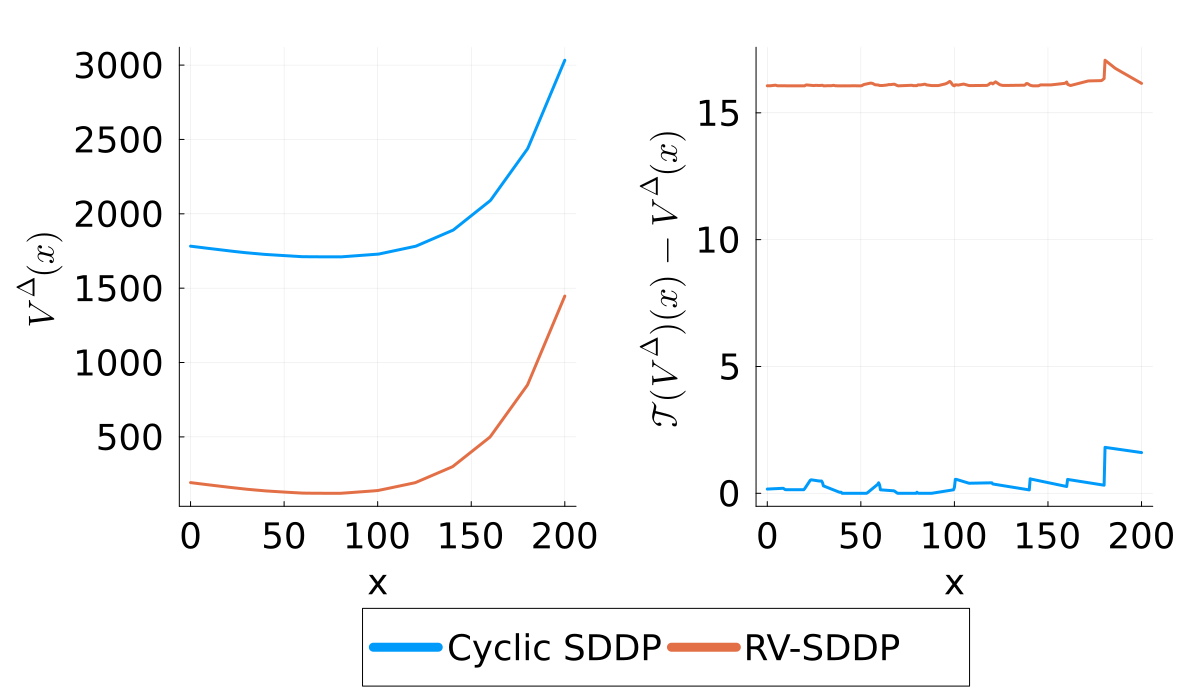

In [63]:
using LaTeXStrings
ind = 0:0.5:200
V_no_shift = [RVSDDP.compute_V(model_no_shift[1].value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
V_RVSDDP = [RVSDDP.compute_V(model_RVSDDP[1].value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]

TV_no_shift = [RVSDDP.compute_TV(model_no_shift[1], Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
TV_RVSDDP = [RVSDDP.compute_TV(model_RVSDDP[1], Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]

p1 = plot(
    ind,
    V_no_shift,
    label = false,
    xlabel = "x",
    ylabel = L"V^\Delta(x)",
    guidefontsize = fontsize,
    tickfontsize = fontsize,
    linewidth = 3,
    margin = 10Plots.mm,
)
plot!(p1, ind, V_RVSDDP, label = false, linewidth = 3)

p2 = plot(
    ind,
    TV_no_shift - V_no_shift,
    label = false,
    xlabel = "x",
    ylabel = L"\mathcal{T}(V^\Delta)(x) - V^\Delta(x)",
    guidefontsize = fontsize,
    tickfontsize = fontsize,
    linewidth = 3,
    margin = 10Plots.mm,
)
plot!(p2, ind, TV_RVSDDP - V_RVSDDP, label = false, linewidth = 3)

pleg = plot(
    [NaN], [NaN],
    label = "Cyclic SDDP",
    linewidth = 3,
    color = 1,
    framestyle = :none,
    legend = :bottom,
    legend_columns = 2,
    legendfontsize = fontsize,
    ticks = false,
    grid = false,
)
plot!(
    pleg,
    [NaN], [NaN],
    label = "RV-SDDP",
    linewidth = 3,
    color = 2,
)

plot(
    p1,
    p2,
    pleg,
    layout = @layout([a b; c{0.12h}]),
    size = (1200, 700),
)
# savefig("results_toy/vf_and_TV-V.png")


In [ ]:
model_no_shift = [RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    ) for iter in 10:10:iter_max]

folder = "results_toy/no_shift_0_parallel_1/$(discount_factor)/seed_1_iter_$(iter_max)" 

for (i, iter) in enumerate(10:10:iter_max)
    RVSDDP._add_cuts_iter(model_no_shift[i], iter, folder);
end

ind = 0:1:200

fontsize = 20

p=plot(xlabel="x", ylabel = L"V^\Delta(x)", guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, size=(1000, 700), margin=10Plots.mm, legend=:outerright)
for k in 1:10
    i = 10-k+1
    iter = i*10
    RVSDDP._add_cuts_iter(model_no_shift[i], iter, folder)
    V_no_shift = [RVSDDP.compute_V(model_no_shift[i][1].value_function, Dict(Symbol("volume[1]")=>1.0*j)) for j in ind]
    plot!(p, ind, V_no_shift, label = latexstring("V^\\Delta_{$iter}(x)"), linewidth = 3)
end
p

# savefig("results_toy/vf_iter_toy.png")

"/home/mathis/Documents/RVSDDP/results_toy/vf_iter_toy.png"